In [4]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

import functions.eddy_feedback as ef
import functions.data_wrangling as dw

# Data Import

In [5]:
path = '/home/links/ct715/data_storage/reanalysis/jra55_daily/processed_efp'

# QG data import
path_6h = os.path.join(path, 'k123_6h_ubar_epf-pr-QG_1MS_1958-2016.nc')
ds_6h = xr.open_dataset(path_6h)
ds_6h = ds_6h.sel(level=slice(950, 100))
ds_6h = ds_6h.sel(lat=slice(0, 87.5))

# Define ubar
ubar = ds_6h['ubar']
ubar_djf = dw.seasonal_mean(ubar, season='djf')
ubar_djf = ubar_djf.mean(dim='time')

# Define div1
div1 = ds_6h['div1_QG']
div1_djf = dw.seasonal_mean(div1, season='djf')
div1_djf = div1_djf.mean(dim='time')

# Define ep2
ep2 = ds_6h['ep2_QG']
ep2_djf = dw.seasonal_mean(ep2, season='djf')
ep2_djf = ep2_djf.mean(dim='time')

# Northern Hemisphere

## DivFy and ubar

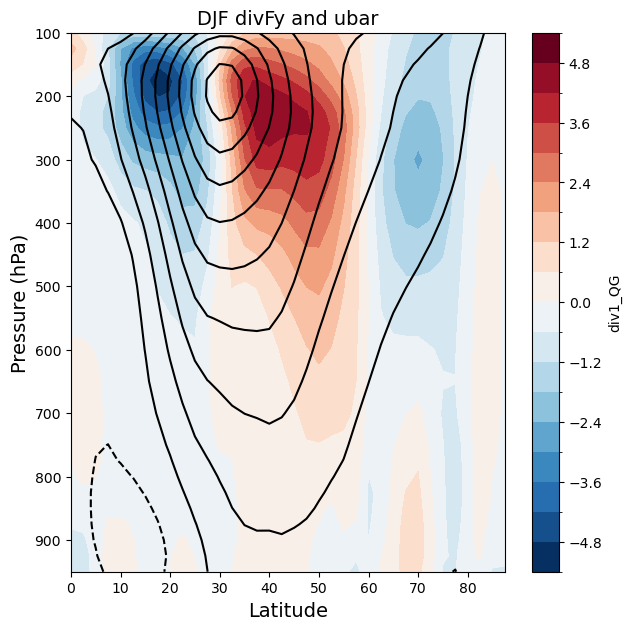

In [17]:
plt.figure(figsize=(7,7))

div1_djf.plot.contourf(x='lat', y='level', levels=20, cmap='RdBu_r', yincrease=False)
ubar_djf.plot.contour(x='lat', y='level', levels=20, colors='k', yincrease=False)
plt.ylabel('Pressure (hPa)', fontsize=14)
plt.xlabel('Latitude', fontsize=14)
plt.title('DJF divFy and ubar', fontsize=14)
plt.show()

# DivFy and Fp

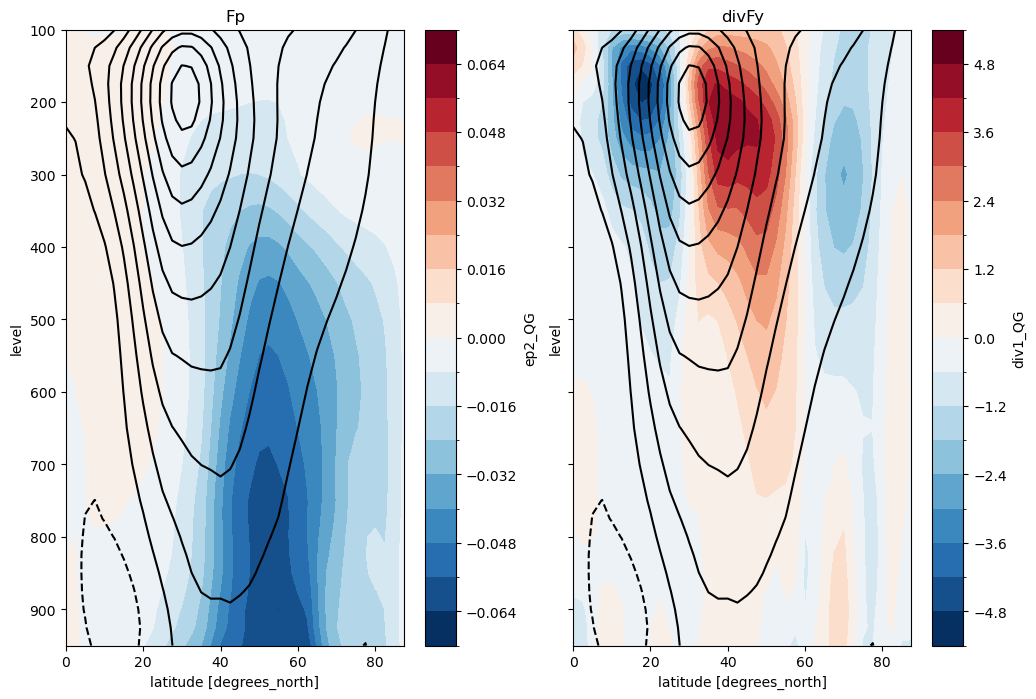

In [7]:
fig, (ax1,ax2) = plt.subplots(ncols=2, figsize=(12, 8), sharey=True)

ep2_djf.plot.contourf(x='lat', y='level', levels=20, cmap='RdBu_r', yincrease=False, ax=ax1)
ubar_djf.plot.contour(x='lat', y='level', levels=20, colors='k', yincrease=False, ax=ax1)
ax1.set_title('Fp')

div1_djf.plot.contourf(x='lat', y='level', levels=20, cmap='RdBu_r', yincrease=False, ax=ax2)
ubar_djf.plot.contour(x='lat', y='level', levels=20, colors='k', yincrease=False, ax=ax2)
ax2.set_title('divFy')

plt.show()

# All EP Fluxes

In [8]:
# Define div2
div2 = ds_6h['div2_QG']
div2_djf = dw.seasonal_mean(div2, season='djf')
div2_djf = div2_djf.mean(dim='time')

# Define ep1
ep1 = ds_6h['ep1_QG']
ep1_djf = dw.seasonal_mean(ep1, season='djf')
ep1_djf = ep1_djf.mean(dim='time')

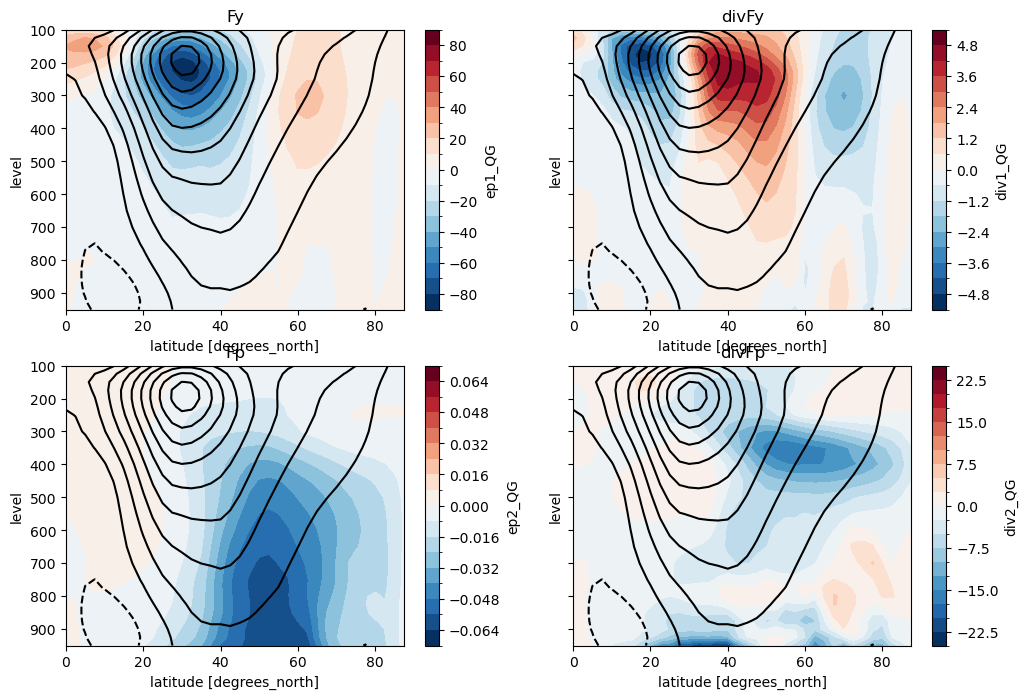

In [12]:
fig, axes = plt.subplots(nrows=2,ncols=2, figsize=(12, 8), sharey=True)

ep1_djf.plot.contourf(x='lat', y='level', levels=20, cmap='RdBu_r', yincrease=False, ax=axes[0,0])
ubar_djf.plot.contour(x='lat', y='level', levels=20, colors='k', yincrease=False, ax=axes[0,0])
axes[0,0].set_title('Fy')

div1_djf.plot.contourf(x='lat', y='level', levels=20, cmap='RdBu_r', yincrease=False, ax=axes[0,1])
ubar_djf.plot.contour(x='lat', y='level', levels=20, colors='k', yincrease=False, ax=axes[0,1])
axes[0,1].set_title('divFy')

ep2_djf.plot.contourf(x='lat', y='level', levels=20, cmap='RdBu_r', yincrease=False, ax=axes[1,0])
ubar_djf.plot.contour(x='lat', y='level', levels=20, colors='k', yincrease=False, ax=axes[1,0])
axes[1,0].set_title('Fp')

div2_djf.plot.contourf(x='lat', y='level', levels=20, cmap='RdBu_r', yincrease=False, ax=axes[1,1])
ubar_djf.plot.contour(x='lat', y='level', levels=20, colors='k', yincrease=False, ax=axes[1,1])
axes[1,1].set_title('divFp')

plt.show()